# Social Network Ads

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')

In [3]:
df=df.iloc[:,2:]

In [4]:
df.sample(5)

,Age,EstimatedSalary,Purchased
200,35,39000,0
307,47,113000,1
247,57,122000,1
399,49,36000,1
27,47,30000,1


In [ ]:
#Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((280, 2), (120, 2))

## Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [7]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [8]:
#Conver X_train_scaled from numpy to data frame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [9]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [10]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Text(0.5, 1.0, 'After Scaling')

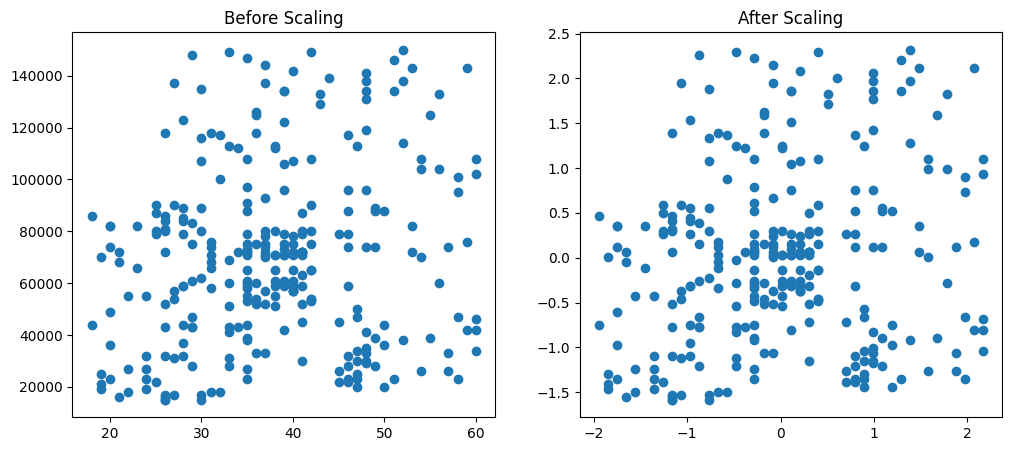

In [ ]:
#Scatterplot
fig, (g1, g2) = plt.subplots(ncols=2, figsize=(12,5))

#Before scaling
g1.scatter(X_train['Age'], X_train['EstimatedSalary'])
g1.set_title("Before Scaling")

#After scaling
g2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'])
g2.set_title("After Scaling")

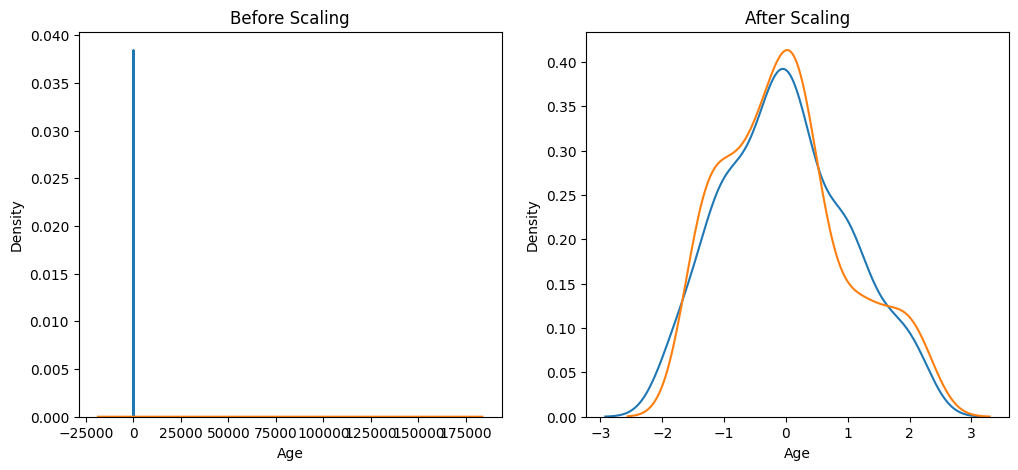

In [ ]:
#Probability density function
fig, (g1, g2)=plt.subplots(ncols=2, figsize=(12,5))

#Before scaling
g1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=g1)
sns.kdeplot(X_train['EstimatedSalary'], ax=g1)

#After scaling
g2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=g2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=g2)
plt.show()

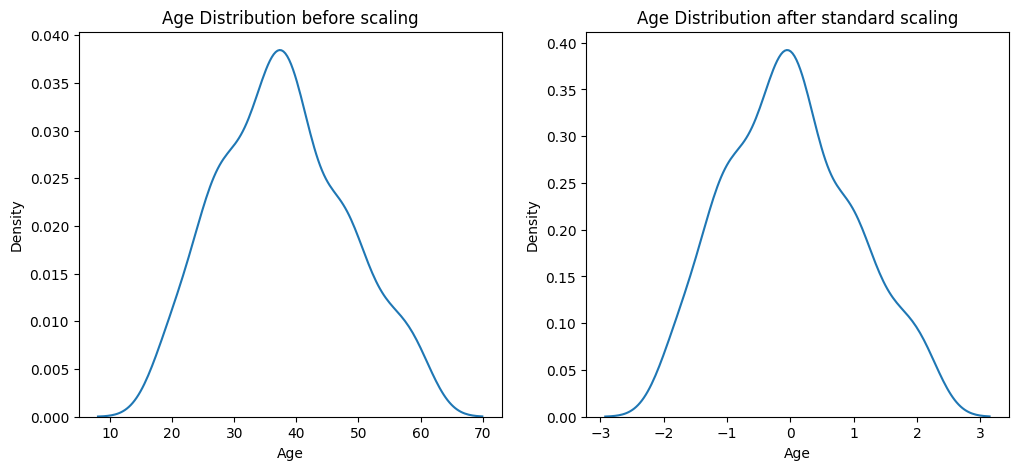

In [ ]:
#Probability density function
fig, (g1, g2)=plt.subplots(ncols=2, figsize=(12, 5))

#Before scaling
g1.set_title('Age Distribution before scaling')
sns.kdeplot(X_train['Age'], ax=g1)

#After scaling
g2.set_title('Age Distribution after standard scaling')
sns.kdeplot(X_train_scaled['Age'], ax=g2)
plt.show()

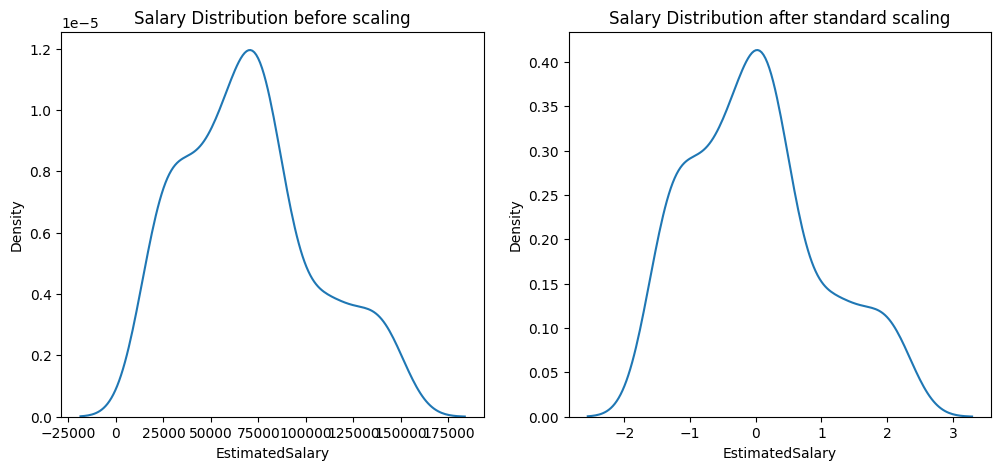

In [14]:
fig, (g1, g2)=plt.subplots(ncols=2, figsize=(12, 5))

#Before scaling
g1.set_title('Salary Distribution before scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=g1)

#After scaling
g2.set_title('Salary Distribution after standard scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=g2)
plt.show()

## Normalization

### Min Max Scaling

In [27]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [18]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()

norm.fit(X_train)

X_train_norm=norm.transform(X_train)
X_test_norm=norm.transform(X_test)

In [19]:
X_train_norm=pd.DataFrame(X_train_norm, columns=X_train.columns)
X_test_norm=pd.DataFrame(X_test_norm, columns=X_test.columns)

In [20]:
np.round(X_train_norm.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.5,0.4
std,0.2,0.3
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.4
75%,0.7,0.5
max,1.0,1.0


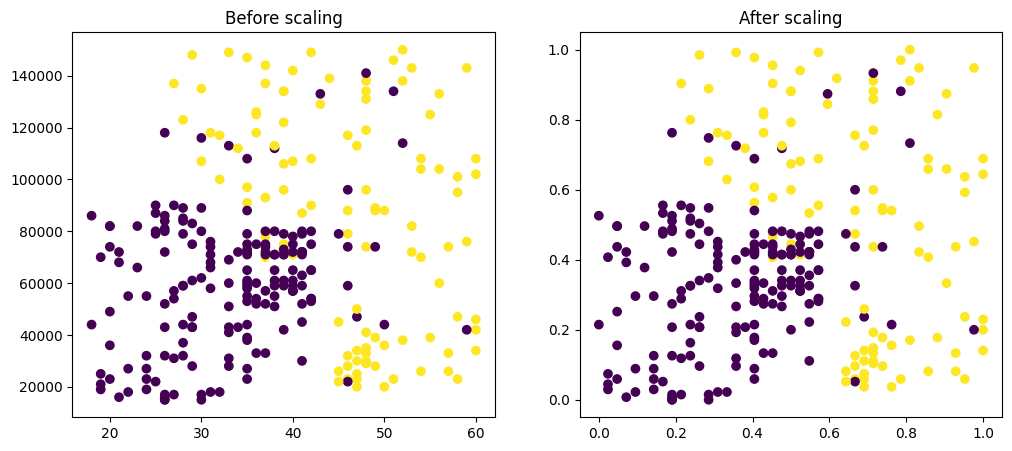

In [21]:
fig, (gr1, gr2)=plt.subplots(ncols=2, figsize=(12,5))

gr1.scatter(X_train['Age'], X_train['EstimatedSalary'], c=y_train)
gr1.set_title("Before scaling")

gr2.scatter(X_train_norm['Age'], X_train_norm['EstimatedSalary'], c=y_train)
gr2.set_title("After scaling")

plt.show()

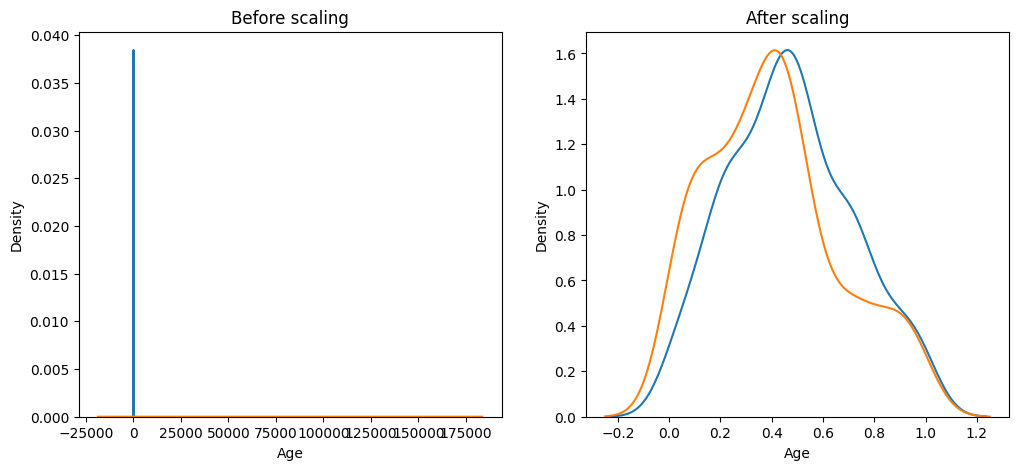

In [23]:
fig, (gr1, gr2)=plt.subplots(ncols=2, figsize=(12,5))

gr1.set_title("Before scaling")
sns.kdeplot(X_train['Age'], ax=gr1)
sns.kdeplot(X_train['EstimatedSalary'], ax=gr1)

gr2.set_title("After scaling")
sns.kdeplot(X_train_norm['Age'], ax=gr2)
sns.kdeplot(X_train_norm['EstimatedSalary'], ax=gr2)

plt.show()

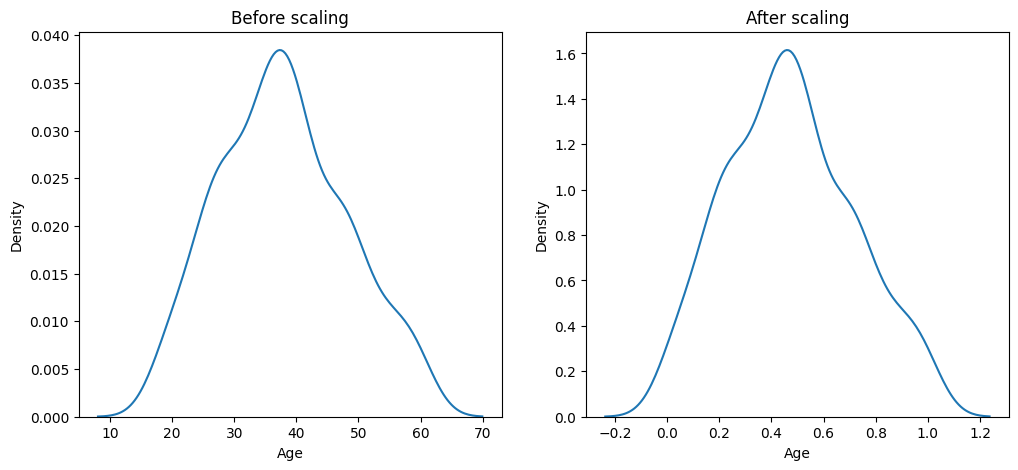

In [24]:
fig, (gr1, gr2)=plt.subplots(ncols=2, figsize=(12,5))

gr1.set_title("Before scaling")
sns.kdeplot(X_train['Age'], ax=gr1)

gr2.set_title("After scaling")
sns.kdeplot(X_train_norm['Age'], ax=gr2)

plt.show()

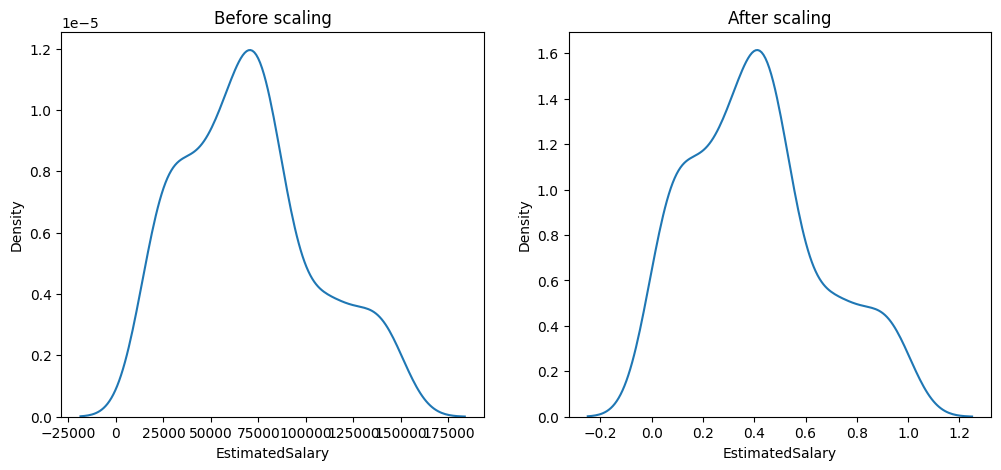

In [26]:
fig, (gr1, gr2)=plt.subplots(ncols=2, figsize=(12,5))

gr1.set_title("Before scaling")
sns.kdeplot(X_train['EstimatedSalary'], ax=gr1)

gr2.set_title("After scaling")
sns.kdeplot(X_train_norm['EstimatedSalary'], ax=gr2)

plt.show()